In [2]:
!pip install matplotlib scikit-learn seaborn pillow 

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

In [ ]:
# ==================== CONFIG ====================
BATCH_SIZE = 16
NUM_EPOCHS = 15
LEARNING_RATE = 0.001
IMAGE_SIZE = (224, 224)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# ==================== DATA AUGMENTATION ====================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

TensorFlow version: 2.10.1
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
train_generator = train_datagen.flow_from_directory(
    'D:/E0323036-SEM6/dl_med/chest_xray/test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = test_datagen.flow_from_directory(
    'D:/E0323036-SEM6/dl_med/chest_xray/val',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    'D:/E0323036-SEM6/dl_med/chest_xray/test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Train samples: {train_generator.samples}")
print(f"Val samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print(f"Classes: {train_generator.class_indices}")



Found 624 images belonging to 2 classes.


Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train samples: 624
Val samples: 16
Test samples: 624
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


In [9]:
# ==================== BUILD CNN MODEL ====================
def build_cnn_model(input_shape=(224, 224, 3), num_classes=2):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 4
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Classifier
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Build model
model = build_cnn_model(input_shape=(224, 224, 3), num_classes=2)
model.summary()

# ==================== COMPILE MODEL ====================
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==================== CALLBACKS ====================
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'pneumonia_model_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ==================== TRAINING ====================
print("\n" + "="*50)
print("Starting Training...")
print("="*50 + "\n")

history = model.fit(
    train_generator,
    epochs=NUM_EPOCHS,
    validation_data=val_generator
)

print("\nTraining Complete!")
print("\n" + "="*50)
print("Testing Model...")
print("="*50 + "\n")


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 112, 112, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_1 (Batc  (None, 112, 112, 64)     2

20/20 [==============================] - 4s 165ms/step
Test Accuracy:  0.6250
Test Precision: 0.3906
Test Recall:    0.6250
Test F1-Score:  0.4808


c:\Users\aida-lab\AppData\Local\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


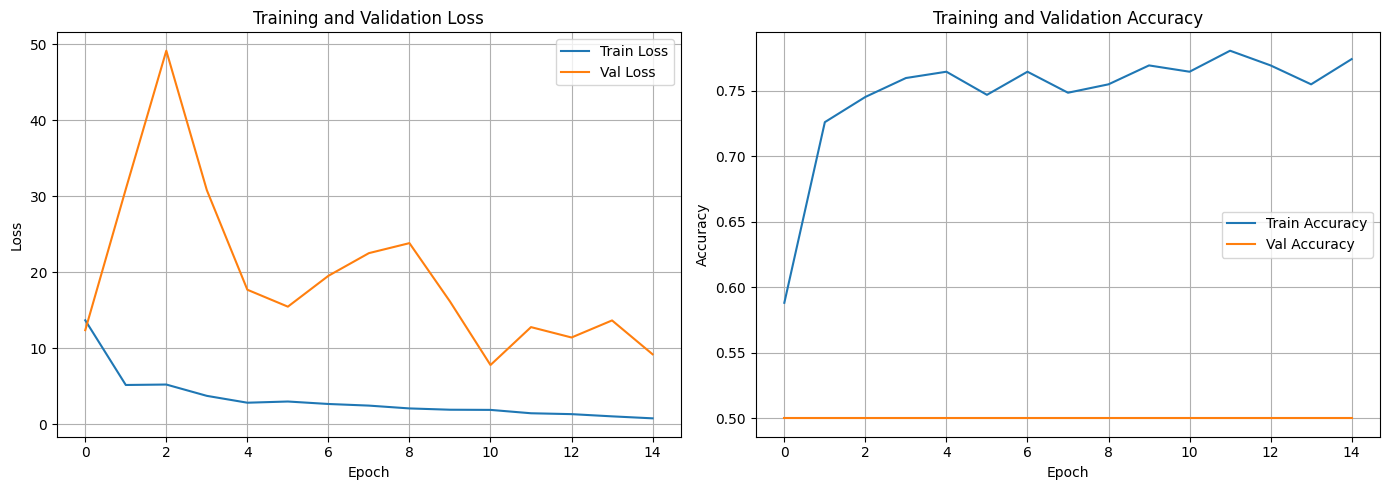

INFO:tensorflow:Assets written to: pneumonia_model_tf\assets


INFO:tensorflow:Assets written to: pneumonia_model_tf\assets



✓ Model saved as 'pneumonia_model.h5'
✓ Model saved as 'pneumonia_model_tf' (TensorFlow format)
✓ Training history saved as 'training_history.png'
✓ Confusion matrix saved as 'confusion_matrix.png'


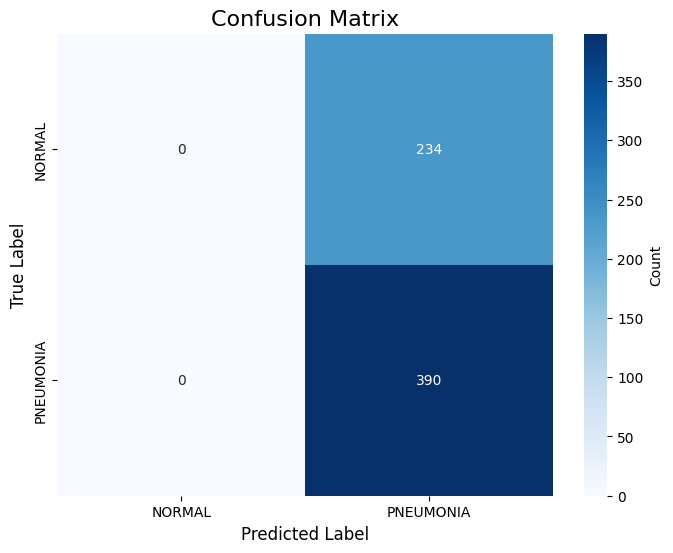

In [10]:

test_predictions = model.predict(test_generator)
test_preds_classes = np.argmax(test_predictions, axis=1)
test_true_labels = test_generator.classes
test_accuracy = accuracy_score(test_true_labels, test_preds_classes)
test_precision = precision_score(test_true_labels, test_preds_classes, average='weighted')
test_recall = recall_score(test_true_labels, test_preds_classes, average='weighted')
test_f1 = f1_score(test_true_labels, test_preds_classes, average='weighted')

print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()
cm = confusion_matrix(test_true_labels, test_preds_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

model.save('pneumonia_model.h5')
model.save('pneumonia_model_tf')

print("\n✓ Model saved as 'pneumonia_model.h5'")
print("✓ Model saved as 'pneumonia_model_tf' (TensorFlow format)")
print("✓ Training history saved as 'training_history.png'")
print("✓ Confusion matrix saved as 'confusion_matrix.png'")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import os

MODEL_DIR = 'D:\E0323036-SEM6\dl_med\pneumonia_model.h5'  # Change this to your model path

try:
    model = tf.keras.models.load_model(MODEL_DIR)
    print(f"✓ Model loaded successfully from {MODEL_DIR}")
except Exception as e:
    print(f" Error loading model: {e}")
    print(f"Make sure the model exists at: {MODEL_DIR}")
    exit(1)

def predict_pneumonia(image_path):
    if not os.path.exists(image_path):
        print(f" Error: Image not found at {image_path}")
        return None, None
    
    try:

        image = load_img(image_path, target_size=(224, 224))
        image_array = img_to_array(image) / 255.0
        image_array = np.expand_dims(image_array, axis=0)

        prediction = model.predict(image_array, verbose=0)
        predicted_class = np.argmax(prediction[0])
        confidence = prediction[0][predicted_class]
        
        class_names = ['NORMAL', 'PNEUMONIA']
        predicted_label = class_names[predicted_class]
        
        print(f"\n{'='*60}")
        print(f"Image: {image_path}")
        print(f"Prediction: {predicted_label}")
        print(f"Confidence: {confidence:.4f}")
        print(f"{'='*60}\n")

        print("Class Probabilities:")
        for class_name, prob in zip(class_names, prediction[0]):
            bar = '█' * int(prob * 30)
            print(f"  {class_name:12} {prob:.4f} {bar}")
        
        return predicted_label, confidence
        
    except Exception as e:
        print(f" Error predicting image: {e}")
        return None, None
if __name__ == "__main__":
    
    image_path = r"D:\E0323036-SEM6\dl_med\chest_xray\test\PNEUMONIA\person1_virus_8.jpeg"

    label, conf = predict_pneumonia(image_path)
    
    if label:
        print(f"\n✓ Prediction completed successfully!")
    else:
        print(f"\n Prediction failed!")

✓ Model loaded successfully from D:\E0323036-SEM6\dl_med\pneumonia_model.h5

Image: D:\E0323036-SEM6\dl_med\chest_xray\test\PNEUMONIA\person1_virus_8.jpeg
Prediction: PNEUMONIA
Confidence: 1.0000

Class Probabilities:
  NORMAL       0.0000 
  PNEUMONIA    1.0000 ██████████████████████████████

✓ Prediction completed successfully!
